In [1]:
"""
COMPARE GEOS-LDAS SURFACE SOIL MOISTURE (SFMC) TO ERA5 SWVL1
==================================================================
This notebook:
 1. Reads the GEOS-LDAS tilecoord binary and model output.
 2. Builds the exact M36 grid geometry from tile bounds.
 3. Regrids ERA5 monthly soil moisture to that grid using xESMF (conservative).
 4. Aggregates model tile data to the same grid (area weighted, land only).
 5. Computes anomaly correlation & ubRMSE between model and ERA5.
"""

import numpy as np
import xarray as xr
import pandas as pd
import struct
import matplotlib.pyplot as plt
import xesmf as xe
import datetime as dt
import os
from collections import OrderedDict

# === File paths (edit for your system) ===
ftc = '/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/land_sweeper/LS_OLv8_M36/output/SMAP_EASEv2_M36_GLOBAL/rc_out/LS_OLv8_M36.ldas_tilecoord.bin'
era_nc = '/Users/amfox/Desktop/geosldas-analysis/era5_monthly_nc/ERA5_monthly_merged.nc'
model_nc = '/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/OLv8_land_variables_2000_2024_compressed.nc'

# choose a filename
out_nc = 'ERA5_vs_OLv8_M36_summary.nc'

In [2]:
# --- SOURCE: 1° global grid (centers + bounds) ---
lon_b_src = np.linspace(0.0, 360.0, 361)          # 361 edges
lat_b_src = np.linspace(-90.0, 90.0, 181)         # 181 edges
lon_src   = 0.5*(lon_b_src[:-1] + lon_b_src[1:])  # 360 centers
lat_src   = 0.5*(lat_b_src[:-1] + lat_b_src[1:])  # 180 centers

src = xr.Dataset(
    {
        "lon":    (("lon",), lon_src),
        "lat":    (("lat",), lat_src),
        "lon_b":  (("lon_b",), lon_b_src),
        "lat_b":  (("lat_b",), lat_b_src),
    }
)
src["lon"].attrs.update(standard_name="longitude", units="degrees_east", bounds="lon_b")
src["lat"].attrs.update(standard_name="latitude",  units="degrees_north", bounds="lat_b")
src["lon_b"].attrs.update(standard_name="longitude", units="degrees_east")
src["lat_b"].attrs.update(standard_name="latitude",  units="degrees_north")

# --- TARGET: 6° global grid ---
lon_b_tgt = np.linspace(0.0, 360.0, 61)           # 61 edges
lat_b_tgt = np.linspace(-90.0, 90.0, 31)          # 31 edges
lon_tgt   = 0.5*(lon_b_tgt[:-1] + lon_b_tgt[1:])  # 60 centers
lat_tgt   = 0.5*(lat_b_tgt[:-1] + lat_b_tgt[1:])  # 30 centers

tgt = xr.Dataset(
    {
        "lon":    (("lon",), lon_tgt),
        "lat":    (("lat",), lat_tgt),
        "lon_b":  (("lon_b",), lon_b_tgt),
        "lat_b":  (("lat_b",), lat_b_tgt),
    }
)
tgt["lon"].attrs.update(standard_name="longitude", units="degrees_east", bounds="lon_b")
tgt["lat"].attrs.update(standard_name="latitude",  units="degrees_north", bounds="lat_b")
tgt["lon_b"].attrs.update(standard_name="longitude", units="degrees_east")
tgt["lat_b"].attrs.update(standard_name="latitude",  units="degrees_north")

# --- Build regridder (conservative works because bounds are present) ---
r = xe.Regridder(src, tgt, method="conservative", periodic=True, reuse_weights=False)
print(r)  # should print weights file info


xESMF Regridder 
Regridding algorithm:       conservative 
Weight filename:            conservative_180x360_30x60.nc 
Reuse pre-computed weights? False 
Input grid shape:           (180, 360) 
Output grid shape:          (30, 60) 
Periodic in longitude?      False


In [3]:
def read_tilecoord(fname):
    """Read GEOS-LDAS tilecoord Fortran binary (little-endian)."""
    int_precision = 'i'
    float_precision = 'f'
    machfmt = '<'
    tile_coord = {}
    with open(fname, 'rb') as ifp:
        _ = struct.unpack(f'{machfmt}i', ifp.read(4))[0]
        tile_coord['N_tile'] = struct.unpack(f'{machfmt}i', ifp.read(4))[0]
        _ = struct.unpack(f'{machfmt}i', ifp.read(4))[0]
        Nt = tile_coord['N_tile']
        fields = ['tile_id','typ','pfaf','com_lon','com_lat','min_lon','max_lon',
                  'min_lat','max_lat','i_indg','j_indg','frac_cell','frac_pfaf',
                  'area','elev']
        for field in fields:
            _ = struct.unpack(f'{machfmt}i', ifp.read(4))[0]
            dtype = int_precision if field in ['tile_id','typ','pfaf','i_indg','j_indg'] else float_precision
            arr = np.frombuffer(ifp.read(Nt*4), dtype=f'{machfmt}{dtype}')
            arr = arr.astype(np.float64 if dtype=='f' else np.int32)
            tile_coord[field] = arr
            _ = struct.unpack(f'{machfmt}i', ifp.read(4))[0]
    return tile_coord

def build_m36_grid_cf(tc):
    """Build exact M36 grid with centers and bounds (CF-compliant) from tilecoord."""
    i_indg = tc['i_indg'].astype(int)
    j_indg = tc['j_indg'].astype(int)
    min_lon, max_lon = tc['min_lon'], tc['max_lon']
    min_lat, max_lat = tc['min_lat'], tc['max_lat']
    nx = int(i_indg.max()) + 1
    ny = int(j_indg.max()) + 1

    lon_b = np.full((ny+1, nx+1), np.nan)
    lat_b = np.full((ny+1, nx+1), np.nan)
    for lon0, lon1, lat0, lat1, i, j in zip(min_lon, max_lon, min_lat, max_lat, i_indg, j_indg):
        lon_b[j, i]     = lon0; lon_b[j, i+1] = lon1
        lon_b[j+1, i]   = lon0; lon_b[j+1, i+1] = lon1
        lat_b[j, i]     = lat0; lat_b[j+1, i]   = lat1
        lat_b[j, i+1]   = lat0; lat_b[j+1, i+1] = lat1

    lon_c = 0.5*(lon_b[:-1,:-1] + lon_b[1:,1:])
    lat_c = 0.5*(lat_b[:-1,:-1] + lat_b[1:,1:])

    m36 = xr.Dataset(
        {"lon": (("y","x"), lon_c),
         "lat": (("y","x"), lat_c),
         "lon_b": (("y_b","x_b"), lon_b),
         "lat_b": (("y_b","x_b"), lat_b)}
    )
    m36["lon"].attrs.update(standard_name="longitude", units="degrees_east", bounds="lon_b")
    m36["lat"].attrs.update(standard_name="latitude",  units="degrees_north", bounds="lat_b")
    m36["lon_b"].attrs.update(standard_name="longitude", units="degrees_east")
    m36["lat_b"].attrs.update(standard_name="latitude",  units="degrees_north")
    return m36

def tiles_to_m36_grid_unweighted(tile_values, tc, m36_grid, land_only=True):
    """
    Map tile values -> M36 grid with a simple (unweighted) mean per cell.
    - Accepts (time, tile) or (tile,) array.
    - Ignores NaN tiles in the per-cell average (no weighting).
    - Returns DataArray (time, y, x). 'time' is 0..T-1 (assign real times after call).
    """
    # tile -> grid indices
    ix = tc["i_indg"].astype(int)
    iy = tc["j_indg"].astype(int)
    ny = int(iy.max()) + 1
    nx = int(ix.max()) + 1

    tv = np.asarray(tile_values)
    if tv.ndim == 1:
        tv = tv[np.newaxis, :]  # (time, tile)
    T, Nt = tv.shape
    assert Nt == ix.size == iy.size, "tile index arrays must match tile dimension"

    # accumulators
    sum_tyx = np.zeros((T, ny, nx), dtype=np.float64)
    cnt_tyx = np.zeros((T, ny, nx), dtype=np.float64)

    for t in range(T):
        v = tv[t]
        ok = np.isfinite(v)  # only finite tiles contribute
        if not np.any(ok):
            continue
        np.add.at(sum_tyx[t], (iy[ok], ix[ok]), v[ok])
        np.add.at(cnt_tyx[t], (iy[ok], ix[ok]), 1.0)

    out = sum_tyx / np.where(cnt_tyx > 0, cnt_tyx, np.nan)

    da = xr.DataArray(
        out,
        dims=("time", "y", "x"),
        coords={
            "time": np.arange(T),
            "lat": (("y", "x"), m36_grid["lat"].values),
            "lon": (("y", "x"), m36_grid["lon"].values),
        },
        attrs={"note": "unweighted mean of tiles per M36 cell"}
    )

    if land_only:
        # mask cells that never received any finite tile across all times
        land_mask = np.isfinite(out).any(axis=0)
        da = da.where(land_mask)

    return da

def layer_weights_era5l(target_top=0.0, target_bot=1.0):
    """Weights for ERA5-Land's 4 layers to represent target depth [m]."""
    # ERA5-Land layer bounds (m):
    bounds = np.array([[0.00,0.07],[0.07,0.28],[0.28,1.00]], dtype=float)
    ov = np.maximum(0.0, np.minimum(bounds[:,1], target_bot) - np.maximum(bounds[:,0], target_top))
    if target_bot - target_top <= 0:
        raise ValueError("target_bot must be > target_top")
    w = ov / (target_bot - target_top)
    return w

def anomalies_monthly(da, dim="time"):
    """
    Monthly anomalies: remove month-of-year climatology (NaN-safe).
    """
    clim = da.groupby(f"{dim}.month").mean(dim=dim, skipna=True)
    return da.groupby(f"{dim}.month") - clim

def anom_metrics_monthly(a, b, dim="time", min_pairs=24):
    """
    NaN-safe anomR and ubRMSE on valid anomaly pairs only.
    Enforces a minimum number of valid pairs (default 24 months).
    """
    valid = xr.where(xr.ufuncs.isfinite(a) & xr.ufuncs.isfinite(b), True, False)
    n = valid.sum(dim=dim)

    a_v = a.where(valid)
    b_v = b.where(valid)

    cov   = (a_v * b_v).mean(dim=dim, skipna=True)
    var_a = (a_v**2).mean(dim=dim, skipna=True)
    var_b = (b_v**2).mean(dim=dim, skipna=True)

    denom = xr.ufuncs.sqrt(var_a * var_b)
    anomR  = xr.where(denom > 0, cov / denom, np.nan)
    ubRMSE = xr.ufuncs.sqrt(((a_v - b_v)**2).mean(dim=dim, skipna=True))

    # require enough valid months
    anomR  = xr.where(n >= min_pairs, anomR, np.nan)
    ubRMSE = xr.where(n >= min_pairs, ubRMSE, np.nan)
    return anomR, ubRMSE

def raw_metrics_monthly(a, b, dim="time", min_pairs=24):
    """
    NaN-safe RMSE and bias on valid raw-value pairs only.
    bias is defined as mean(a - b).
    Enforces a minimum number of valid pairs (default 24 months).
    """
    valid = xr.where(xr.ufuncs.isfinite(a) & xr.ufuncs.isfinite(b), True, False)
    n = valid.sum(dim=dim)

    a_v = a.where(valid)
    b_v = b.where(valid)
    d = a_v - b_v

    rmse = xr.ufuncs.sqrt((d**2).mean(dim=dim, skipna=True))
    bias = d.mean(dim=dim, skipna=True)

    rmse = xr.where(n >= min_pairs, rmse, np.nan)
    bias = xr.where(n >= min_pairs, bias, np.nan)
    return rmse, bias


In [4]:
# Read tilecoord and build grid
tc = read_tilecoord(ftc)
print(f"N_tile = {tc['N_tile']}")
m36_grid = build_m36_grid_cf(tc)
ny, nx = m36_grid.dims["y"], m36_grid.dims["x"]
print("M36 grid:", ny, "x", nx)

# Load model monthly (tile-based)
ds_mod = xr.open_dataset(model_nc)
ds_mod = xr.decode_cf(ds_mod)  # ensure time decoding

# Surface SM (tiles → M36)
sfmc_tiles = ds_mod["SFMC"].values.astype(np.float64)  # (time, tile)
sfmc_grid  = tiles_to_m36_grid_unweighted(sfmc_tiles, tc, m36_grid, land_only=True)
sfmc_grid = sfmc_grid.assign_coords(time=ds_mod["time"].values)
print("SFMC grid shape:", sfmc_grid.shape)

# Optional RZMC
rzmc_grid = None
if "RZMC" in ds_mod.data_vars:
    rzmc_tiles = ds_mod["RZMC"].values.astype(np.float64)
    rzmc_grid  = tiles_to_m36_grid_unweighted(rzmc_tiles, tc, m36_grid, land_only=True)
    rzmc_grid  = rzmc_grid.assign_coords(time=ds_mod["time"].values)
    print("RZMC grid shape:", rzmc_grid.shape)
else:
    print("RZMC not present in model file; skipping model RZ comparison for now.")

# Model snow cover fraction (required for snow-domain mask)
scf_grid = None
if "FRLANDSNO" in ds_mod.data_vars:
    scf_tiles = ds_mod["FRLANDSNO"].values.astype(np.float64)   # units: 1 (0–1)
    scf_grid  = tiles_to_m36_grid_unweighted(scf_tiles, tc, m36_grid, land_only=True)
    scf_grid  = scf_grid.assign_coords(time=ds_mod["time"].values)
    print("SCF (FRLANDSNO) grid shape:", scf_grid.shape)
else:
    print("FRLANDSNO not present in model file; skipping SCF.")

# Optional soil temperature
tsoil1_grid = None
if "TSOIL1" in ds_mod.data_vars:
    tsoil1_tiles = ds_mod["TSOIL1"].values.astype(np.float64)   # units: K
    tsoil1_grid  = tiles_to_m36_grid_unweighted(tsoil1_tiles, tc, m36_grid, land_only=True)
    tsoil1_grid  = tsoil1_grid.assign_coords(time=ds_mod["time"].values)
    print("TSOIL1 grid shape:", tsoil1_grid.shape)
else:
    print("TSOIL1 not present in model file; skipping soil temperature.")

# NEW: Model SWE in m water equivalent (SNOMASLAND is kg m-2)
swe_model_grid = None
if "SNOMASLAND" in ds_mod.data_vars:
    swe_tiles_mwe = ds_mod["SNOMASLAND"].values.astype(np.float64) / 1000.0
    swe_model_grid = tiles_to_m36_grid_unweighted(swe_tiles_mwe, tc, m36_grid, land_only=True)
    swe_model_grid = swe_model_grid.assign_coords(time=ds_mod["time"].values)
    print("SWE model grid shape:", swe_model_grid.shape)
else:
    print("SNOMASLAND not present in model file; skipping SWE comparison.")

# NEW: Model snow depth (grid-cell mean) = SNODPLAND * FRLANDSNO
snwd_model_grid = None
if ("SNODPLAND" in ds_mod.data_vars) and ("FRLANDSNO" in ds_mod.data_vars):
    snwd_tiles_m = (
        ds_mod["SNODPLAND"].values.astype(np.float64)
        * ds_mod["FRLANDSNO"].values.astype(np.float64)
    )
    snwd_model_grid = tiles_to_m36_grid_unweighted(snwd_tiles_m, tc, m36_grid, land_only=True)
    snwd_model_grid = snwd_model_grid.assign_coords(time=ds_mod["time"].values)
    print("Snow depth model grid shape:", snwd_model_grid.shape)
else:
    print("Need SNODPLAND and FRLANDSNO in model file; skipping snow depth comparison.")

N_tile = 112573


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_702/3895202209.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ny, nx = m36_grid.dims["y"], m36_grid.dims["x"]


M36 grid: 379 x 964
SFMC grid shape: (288, 379, 964)
RZMC grid shape: (288, 379, 964)
SCF (FRLANDSNO) grid shape: (288, 379, 964)
TSOIL1 grid shape: (288, 379, 964)
SWE model grid shape: (288, 379, 964)
Snow depth model grid shape: (288, 379, 964)


In [5]:
# Load ERA5 monthly (soil water layers + stl1 + snow vars)
ds_era = xr.open_dataset(era_nc)

# Ensure we have a 'time' coord
if 'valid_time' in ds_era:
    ds_era = ds_era.rename({'valid_time': 'time'})

# Ensure lat ascending and lon in [0,360)
if ds_era.latitude[0] > ds_era.latitude[-1]:
    ds_era = ds_era.reindex(latitude=list(reversed(ds_era.latitude.values)))
ds_era = ds_era.assign_coords(longitude=np.mod(ds_era.longitude, 360.0)).sortby("longitude")

# Intersect time with model if available
if 'time' in ds_mod and 'time' in ds_era:
    common_time = np.intersect1d(ds_mod['time'].values, ds_era['time'].values)
    ds_era = ds_era.sel(time=common_time)

# Build regridder
WEIGHTS = "weights_era5_to_m36_consnormed.nc"
if os.path.exists(WEIGHTS):
    regridder = xe.Regridder(
        ds_era, m36_grid,
        method="conservative_normed",
        periodic=True,
        filename=WEIGHTS,
        reuse_weights=True,
    )
else:
    regridder = xe.Regridder(
        ds_era, m36_grid,
        method="conservative_normed",
        periodic=True,
        filename=WEIGHTS,
        reuse_weights=False,
    )
print(regridder)

# ERA5 soil moisture layers
era_swvl1 = regridder(ds_era["swvl1"]).rename("ERA5_swvl1")
era_swvl2 = regridder(ds_era["swvl2"]).rename("ERA5_swvl2")
era_swvl3 = regridder(ds_era["swvl3"]).rename("ERA5_swvl3")

# ERA5 soil temperature
era_stl1_K = regridder(ds_era["stl1"]).rename("ERA5_stl1")

# ERA5 snow variables
RW = 1000.0  # water density (kg/m^3)
sd = ds_era["sd"]  # SWE thickness (m w.e.)
rsn = ds_era["rsn"] if "rsn" in ds_era.variables else None

# SCF derived from sd and rsn (legacy approach retained)
if rsn is not None:
    snow_cover = (RW * sd / rsn) / 0.1
    snow_cover = snow_cover.where((rsn > 0) & np.isfinite(rsn))
    snow_cover = snow_cover.clip(0.0, 1.0)
    era_snow_frac = regridder(snow_cover).rename("ERA5_snow_frac")
else:
    era_snow_frac = regridder(xr.where(sd > 0.0, 1.0, 0.0)).rename("ERA5_snow_frac")

# NEW: ERA SWE in m water equivalent
era_swe_mwe = regridder(sd).rename("ERA5_swe")

# NEW: ERA snow depth in m (from sd and rsn)
if rsn is not None:
    era_snwd_native = (RW * sd / rsn).where((rsn > 0) & np.isfinite(rsn))
    era_snwd_native = era_snwd_native.where(np.isfinite(era_snwd_native))
    era_snwd_m = regridder(era_snwd_native).rename("ERA5_snwd")
else:
    era_snwd_m = None

print(
    "ERA5 regridded shapes:",
    era_swvl1.shape, era_swvl2.shape, era_swvl3.shape,
    era_stl1_K.shape, era_snow_frac.shape, era_swe_mwe.shape,
    (era_snwd_m.shape if era_snwd_m is not None else "snwd_missing"),
)


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/xesmf/backend.py:56: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


xESMF Regridder 
Regridding algorithm:       conservative_normed 
Weight filename:            weights_era5_to_m36_consnormed.nc 
Reuse pre-computed weights? True 
Input grid shape:           (721, 1440) 
Output grid shape:          (379, 964) 
Periodic in longitude?      False


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/xesmf/smm.py:131: UserWa

ERA5 regridded shapes: (288, 379, 964) (288, 379, 964) (288, 379, 964) (288, 379, 964) (288, 379, 964) (288, 379, 964) (288, 379, 964)


In [6]:
# Inputs (already on M36 grid):
# Model: sfmc_grid, rzmc_grid (optional), scf_grid, tsoil1_grid, swe_model_grid, snwd_model_grid
# ERA:   era_swvl1, era_swvl2, era_swvl3, era_stl1_K, era_snow_frac, era_swe_mwe, era_snwd_m

def _to_month_period(dt64):
    dt = pd.to_datetime(dt64)
    return dt.to_period('M')

# Basic required fields for requested comparisons
if scf_grid is None:
    raise RuntimeError("Model FRLANDSNO missing; cannot compute ever_snow_both mask.")
if swe_model_grid is None:
    raise RuntimeError("Model SNOMASLAND missing; cannot compare SWE.")
if snwd_model_grid is None:
    raise RuntimeError("Model SNODPLAND and/or FRLANDSNO missing; cannot compare snow depth.")
if era_snwd_m is None:
    raise RuntimeError("ERA snow depth could not be derived (missing rsn); cannot compare snow depth.")

# Determine ERA time coord name
tname = 'valid_time' if 'valid_time' in era_swvl1.dims or 'valid_time' in era_swvl1.coords else 'time'

# Sort by time
sfmc_grid       = sfmc_grid.sortby('time')
scf_grid        = scf_grid.sortby('time')
swe_model_grid  = swe_model_grid.sortby('time')
snwd_model_grid = snwd_model_grid.sortby('time')

if tsoil1_grid is not None:
    tsoil1_grid = tsoil1_grid.sortby('time')
if rzmc_grid is not None:
    rzmc_grid = rzmc_grid.sortby('time')

era_swvl1     = era_swvl1.sortby(tname)
era_swvl2     = era_swvl2.sortby(tname)
era_swvl3     = era_swvl3.sortby(tname)
era_stl1_K    = era_stl1_K.sortby(tname)
era_snow_frac = era_snow_frac.sortby(tname)
era_swe_mwe   = era_swe_mwe.sortby(tname)
era_snwd_m    = era_snwd_m.sortby(tname)

# Drop duplicate months (keep first)
_, idx_mod_unique = np.unique(_to_month_period(sfmc_grid['time'].values), return_index=True)
idx_mod_unique = np.sort(idx_mod_unique)

sfmc_grid       = sfmc_grid.isel(time=idx_mod_unique)
scf_grid        = scf_grid.isel(time=idx_mod_unique)
swe_model_grid  = swe_model_grid.isel(time=idx_mod_unique)
snwd_model_grid = snwd_model_grid.isel(time=idx_mod_unique)
if tsoil1_grid is not None:
    tsoil1_grid = tsoil1_grid.isel(time=idx_mod_unique)
if rzmc_grid is not None:
    rzmc_grid = rzmc_grid.isel(time=idx_mod_unique)

_, idx_era_unique = np.unique(_to_month_period(era_swvl1[tname].values), return_index=True)
idx_era_unique = np.sort(idx_era_unique)

era_swvl1     = era_swvl1.isel({tname: idx_era_unique})
era_swvl2     = era_swvl2.isel({tname: idx_era_unique})
era_swvl3     = era_swvl3.isel({tname: idx_era_unique})
era_stl1_K    = era_stl1_K.isel({tname: idx_era_unique})
era_snow_frac = era_snow_frac.isel({tname: idx_era_unique})
era_swe_mwe   = era_swe_mwe.isel({tname: idx_era_unique})
era_snwd_m    = era_snwd_m.isel({tname: idx_era_unique})

# Intersect by monthly period strings
ym_mod = _to_month_period(sfmc_grid['time'].values)
ym_era = _to_month_period(era_swvl1[tname].values)
commonM = np.intersect1d(ym_mod.astype(str), ym_era.astype(str))
assert commonM.size > 0, "No overlapping months between model and ERA5."

midx = np.isin(ym_mod.astype(str), commonM)
eidx = np.isin(ym_era.astype(str), commonM)

# Subset model
sfmc_aln       = sfmc_grid.isel(time=np.where(midx)[0])
scf_aln        = scf_grid.isel(time=np.where(midx)[0])
swe_model_aln  = swe_model_grid.isel(time=np.where(midx)[0])
snwd_model_aln = snwd_model_grid.isel(time=np.where(midx)[0])

if tsoil1_grid is not None:
    tsoil1_aln = tsoil1_grid.isel(time=np.where(midx)[0])
else:
    tsoil1_aln = xr.full_like(sfmc_aln, np.nan)

if rzmc_grid is not None:
    rzmc_aln = rzmc_grid.isel(time=np.where(midx)[0])
else:
    rzmc_aln = None

# Subset ERA
era_sfc_aln  = era_swvl1.isel({tname: np.where(eidx)[0]})
era_l2_aln   = era_swvl2.isel({tname: np.where(eidx)[0]})
era_l3_aln   = era_swvl3.isel({tname: np.where(eidx)[0]})
era_t1_aln   = era_stl1_K.isel({tname: np.where(eidx)[0]})
era_scf_aln  = era_snow_frac.isel({tname: np.where(eidx)[0]})
era_swe_aln  = era_swe_mwe.isel({tname: np.where(eidx)[0]})
era_snwd_aln = era_snwd_m.isel({tname: np.where(eidx)[0]})

# Assign shared end-of-month timestamp and rename ERA time -> 'time'
common_ts = pd.PeriodIndex(commonM, freq='M').to_timestamp('M')

sfmc_aln       = sfmc_aln.assign_coords(time=common_ts)
scf_aln        = scf_aln.assign_coords(time=common_ts)
swe_model_aln  = swe_model_aln.assign_coords(time=common_ts)
snwd_model_aln = snwd_model_aln.assign_coords(time=common_ts)
tsoil1_aln     = tsoil1_aln.assign_coords(time=common_ts)
if rzmc_aln is not None:
    rzmc_aln = rzmc_aln.assign_coords(time=common_ts)

era_sfc_aln  = era_sfc_aln.assign_coords({tname: common_ts}).rename({tname: 'time'})
era_l2_aln   = era_l2_aln.assign_coords({tname: common_ts}).rename({tname: 'time'})
era_l3_aln   = era_l3_aln.assign_coords({tname: common_ts}).rename({tname: 'time'})
era_t1_aln   = era_t1_aln.assign_coords({tname: common_ts}).rename({tname: 'time'})
era_scf_aln  = era_scf_aln.assign_coords({tname: common_ts}).rename({tname: 'time'})
era_swe_aln  = era_swe_aln.assign_coords({tname: common_ts}).rename({tname: 'time'})
era_snwd_aln = era_snwd_aln.assign_coords({tname: common_ts}).rename({tname: 'time'})

# ERA RZSM (0–100 cm)
w = layer_weights_era5l(0.0, 1.0)
era_rz_aln = (w[0]*era_sfc_aln + w[1]*era_l2_aln + w[2]*era_l3_aln).rename('ERA5_RZSM')

# Ensure float dtype
sfmc_aln       = sfmc_aln.astype('float64')
scf_aln        = scf_aln.astype('float64')
swe_model_aln  = swe_model_aln.astype('float64')
snwd_model_aln = snwd_model_aln.astype('float64')
tsoil1_aln     = tsoil1_aln.astype('float64')
rzmc_aln       = rzmc_aln.astype('float64') if rzmc_aln is not None else None

era_sfc_aln  = era_sfc_aln.astype('float64')
era_l2_aln   = era_l2_aln.astype('float64')
era_l3_aln   = era_l3_aln.astype('float64')
era_t1_aln   = era_t1_aln.astype('float64')
era_scf_aln  = era_scf_aln.astype('float64')
era_swe_aln  = era_swe_aln.astype('float64')
era_snwd_aln = era_snwd_aln.astype('float64')
era_rz_aln   = era_rz_aln.astype('float64')

print(f"Aligned months: {sfmc_aln.time.size} from {str(sfmc_aln.time.values[0])[:10]} to {str(sfmc_aln.time.values[-1])[:10]}")
print("RZ weights (0–100 cm):", w, "sum =", w.sum())


Aligned months: 288 from 2000-06-30 to 2024-05-31
RZ weights (0–100 cm): [0.07 0.21 0.72] sum = 1.0


Surface SM (SFMC vs swvl1)  2002-06  MOD[min,max]=[0.0158, 0.8232]  ERA[min,max]=[-0.0001, 0.7335]  DIFF[min,max]=[-0.5403, 0.8032]
Surface SM (SFMC vs swvl1)  2002-08  MOD[min,max]=[0.0171, 0.8296]  ERA[min,max]=[-0.0001, 0.6999]  DIFF[min,max]=[-0.5224, 0.8097]
Surface SM (SFMC vs swvl1)  2005-03  MOD[min,max]=[0.0066, 0.8154]  ERA[min,max]=[-0.0000, 0.7443]  DIFF[min,max]=[-0.5763, 0.7955]
Surface SM (SFMC vs swvl1)  2010-07  MOD[min,max]=[0.0086, 0.8178]  ERA[min,max]=[-0.0001, 0.6955]  DIFF[min,max]=[-0.5363, 0.8115]
Surface SM (SFMC vs swvl1)  2010-08  MOD[min,max]=[0.0123, 0.8278]  ERA[min,max]=[-0.0003, 0.7015]  DIFF[min,max]=[-0.5068, 0.8198]
Surface SM (SFMC vs swvl1)  2013-01  MOD[min,max]=[0.0088, 0.8122]  ERA[min,max]=[-0.0001, 0.7122]  DIFF[min,max]=[-0.5598, 0.8112]
Surface SM (SFMC vs swvl1)  2015-08  MOD[min,max]=[0.0106, 0.8130]  ERA[min,max]=[-0.0001, 0.7011]  DIFF[min,max]=[-0.5286, 0.8007]
Surface SM (SFMC vs swvl1)  2016-12  MOD[min,max]=[0.0123, 0.8056]  ERA[min,

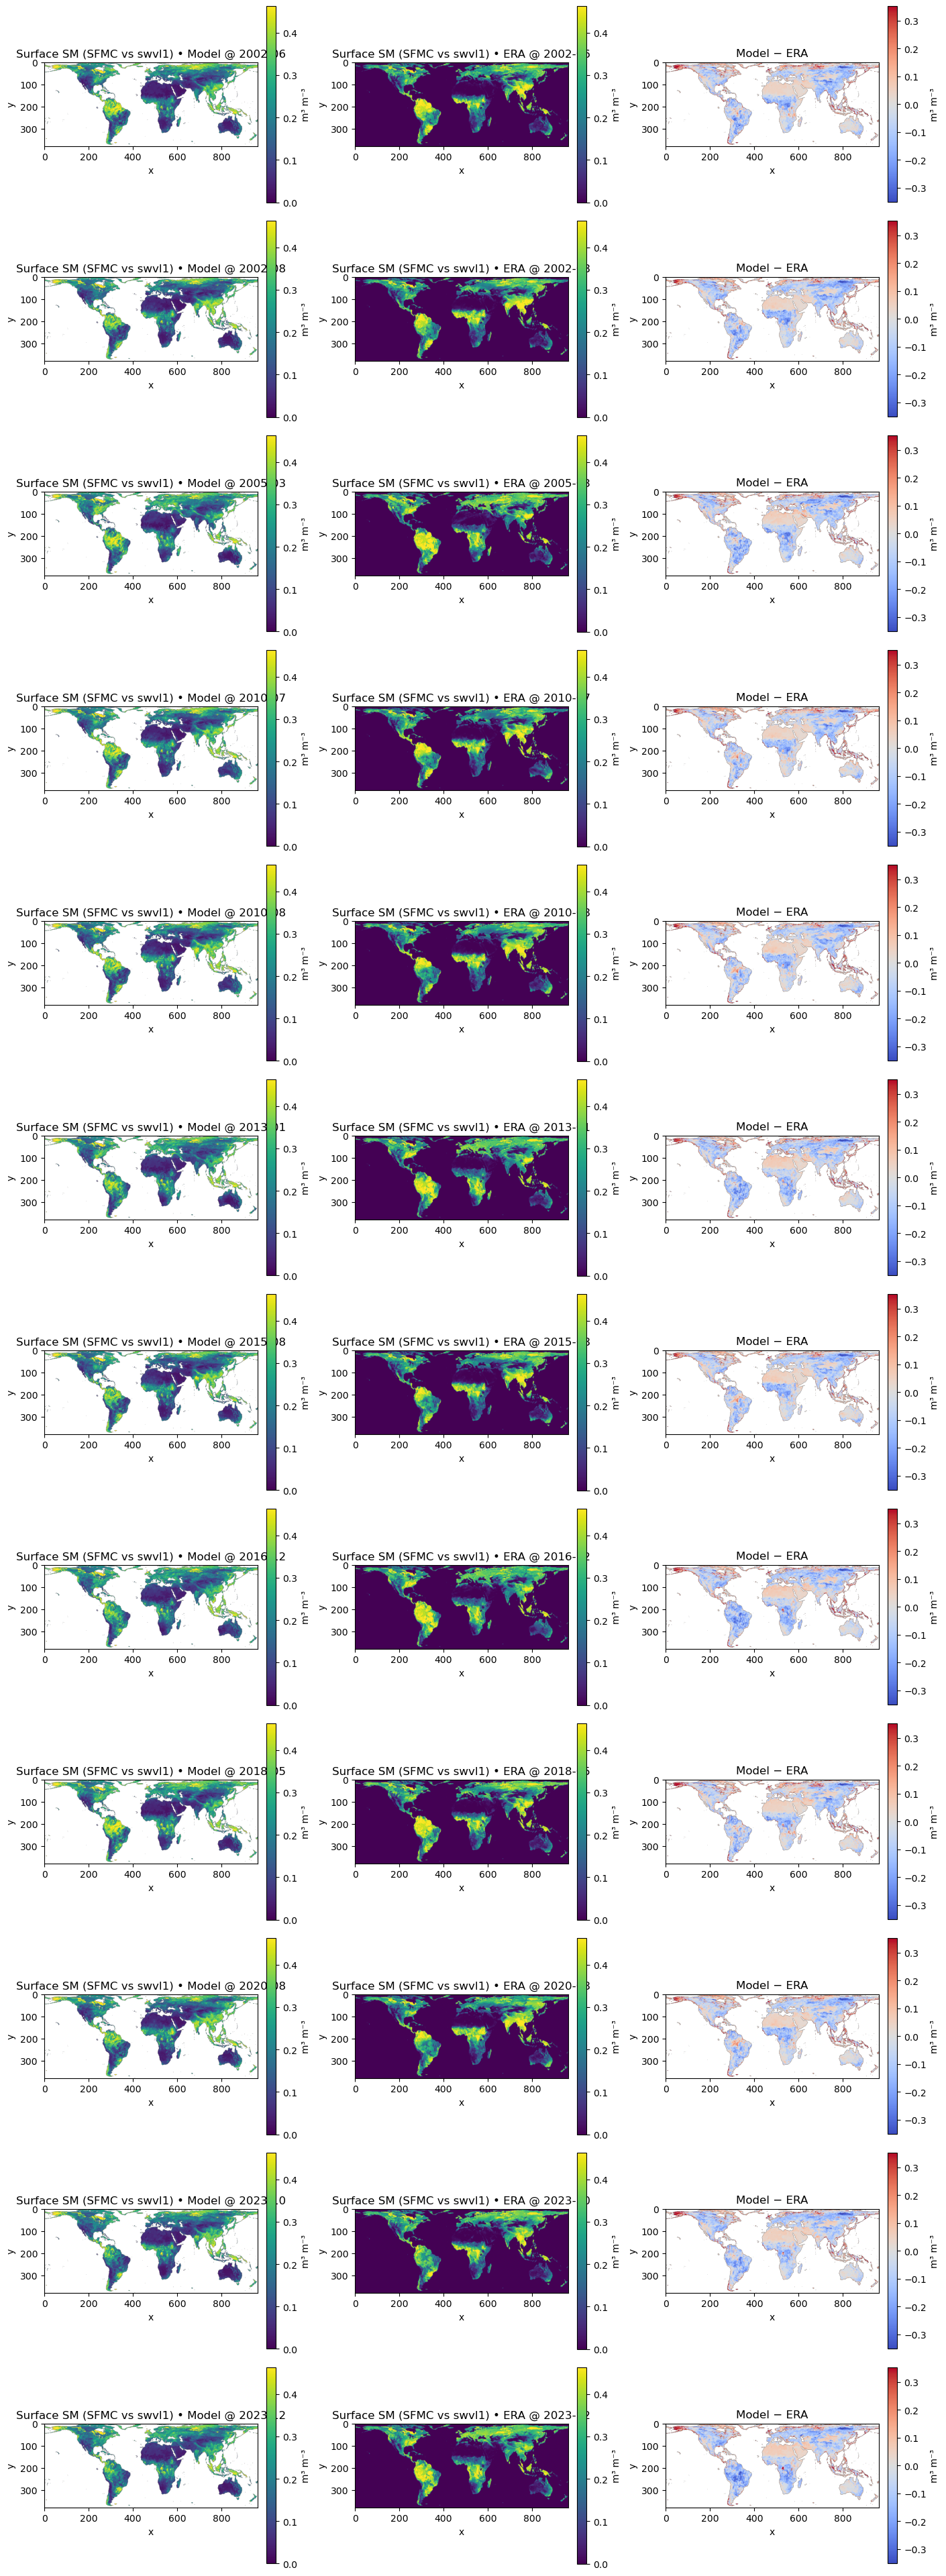


Surface SM (SFMC vs swvl1) • Overall across sampled months:
  MOD  min/max: [0.0066, 0.8411]
  ERA  min/max: [-0.0017, 0.7596]
  DIFF min/max: [-0.5933, 0.8267]

Root-zone SM (RZMC vs ERA RZ)  2002-06  MOD[min,max]=[0.0083, 0.9257]  ERA[min,max]=[0.0000, 0.7242]  DIFF[min,max]=[-0.5721, 0.9197]
Root-zone SM (RZMC vs ERA RZ)  2002-08  MOD[min,max]=[0.0073, 0.9264]  ERA[min,max]=[-0.0000, 0.7026]  DIFF[min,max]=[-0.5881, 0.9228]
Root-zone SM (RZMC vs ERA RZ)  2005-03  MOD[min,max]=[0.0078, 0.9246]  ERA[min,max]=[-0.0000, 0.6804]  DIFF[min,max]=[-0.5318, 0.9224]
Root-zone SM (RZMC vs ERA RZ)  2010-07  MOD[min,max]=[0.0103, 0.9248]  ERA[min,max]=[-0.0000, 0.7030]  DIFF[min,max]=[-0.5628, 0.9221]
Root-zone SM (RZMC vs ERA RZ)  2010-08  MOD[min,max]=[0.0088, 0.9262]  ERA[min,max]=[-0.0000, 0.7064]  DIFF[min,max]=[-0.5514, 0.9231]
Root-zone SM (RZMC vs ERA RZ)  2013-01  MOD[min,max]=[0.0079, 0.9241]  ERA[min,max]=[-0.0000, 0.6964]  DIFF[min,max]=[-0.5349, 0.9236]
Root-zone SM (RZMC vs ERA RZ

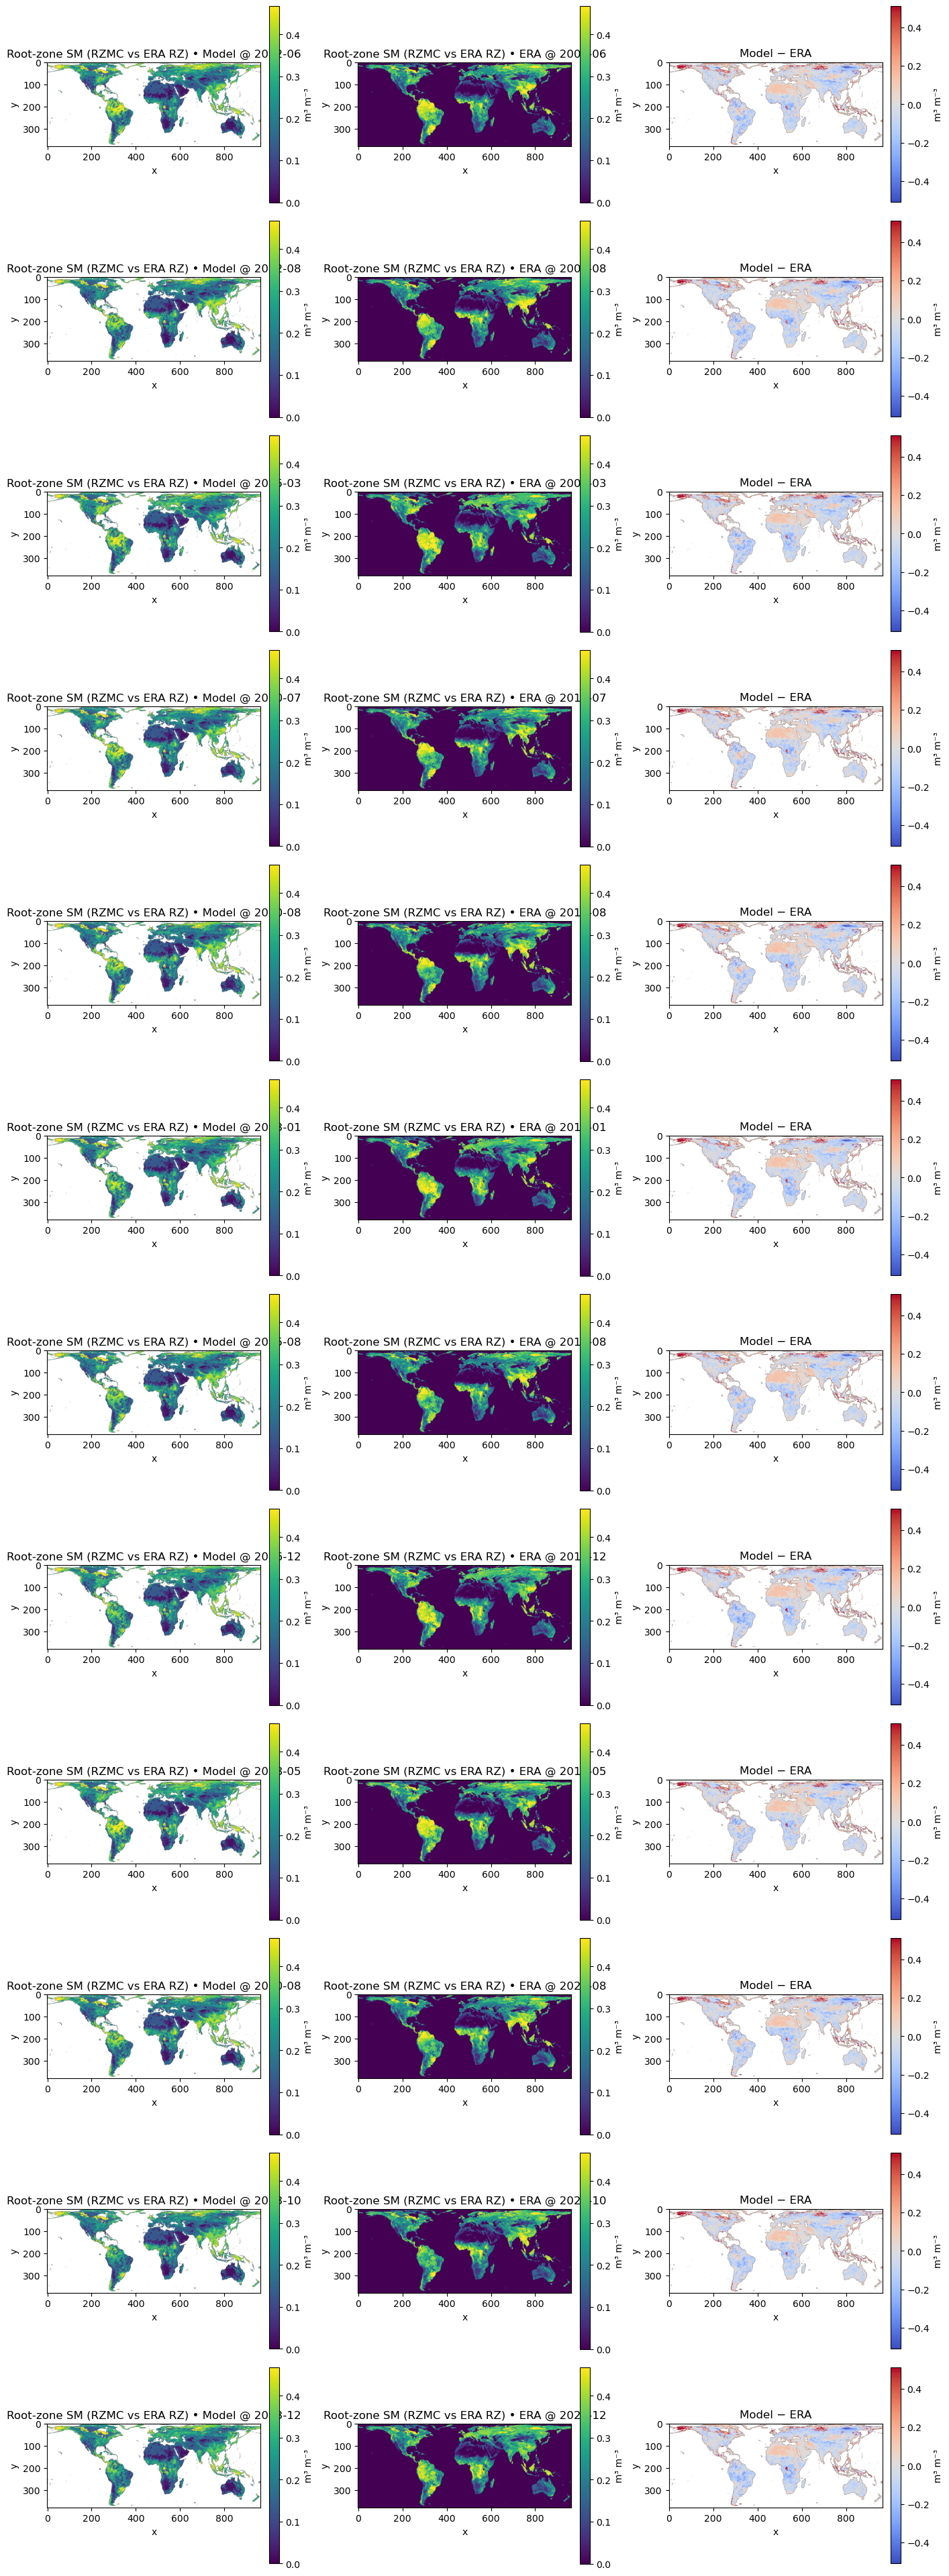


Root-zone SM (RZMC vs ERA RZ) • Overall across sampled months:
  MOD  min/max: [0.0066, 0.9277]
  ERA  min/max: [-0.0000, 0.7242]
  DIFF min/max: [-0.5881, 0.9262]

Soil Temperature (TSOIL1 vs stl1)  2002-06  MOD[min,max]=[251.5244, 317.8524]  ERA[min,max]=[0.0000, 317.2437]  DIFF[min,max]=[-12.8180, 38.2328]
Soil Temperature (TSOIL1 vs stl1)  2002-08  MOD[min,max]=[255.7734, 319.3587]  ERA[min,max]=[0.0000, 316.4704]  DIFF[min,max]=[-13.0403, 28.3999]
Soil Temperature (TSOIL1 vs stl1)  2005-03  MOD[min,max]=[240.2901, 316.5997]  ERA[min,max]=[0.0000, 312.7311]  DIFF[min,max]=[-18.3309, 25.2074]
Soil Temperature (TSOIL1 vs stl1)  2010-07  MOD[min,max]=[255.5306, 317.4843]  ERA[min,max]=[0.0000, 317.2265]  DIFF[min,max]=[-13.5680, 32.2370]
Soil Temperature (TSOIL1 vs stl1)  2010-08  MOD[min,max]=[256.8725, 319.1995]  ERA[min,max]=[0.0000, 316.0999]  DIFF[min,max]=[-12.5049, 26.0240]
Soil Temperature (TSOIL1 vs stl1)  2013-01  MOD[min,max]=[237.3350, 313.8523]  ERA[min,max]=[0.0000, 314

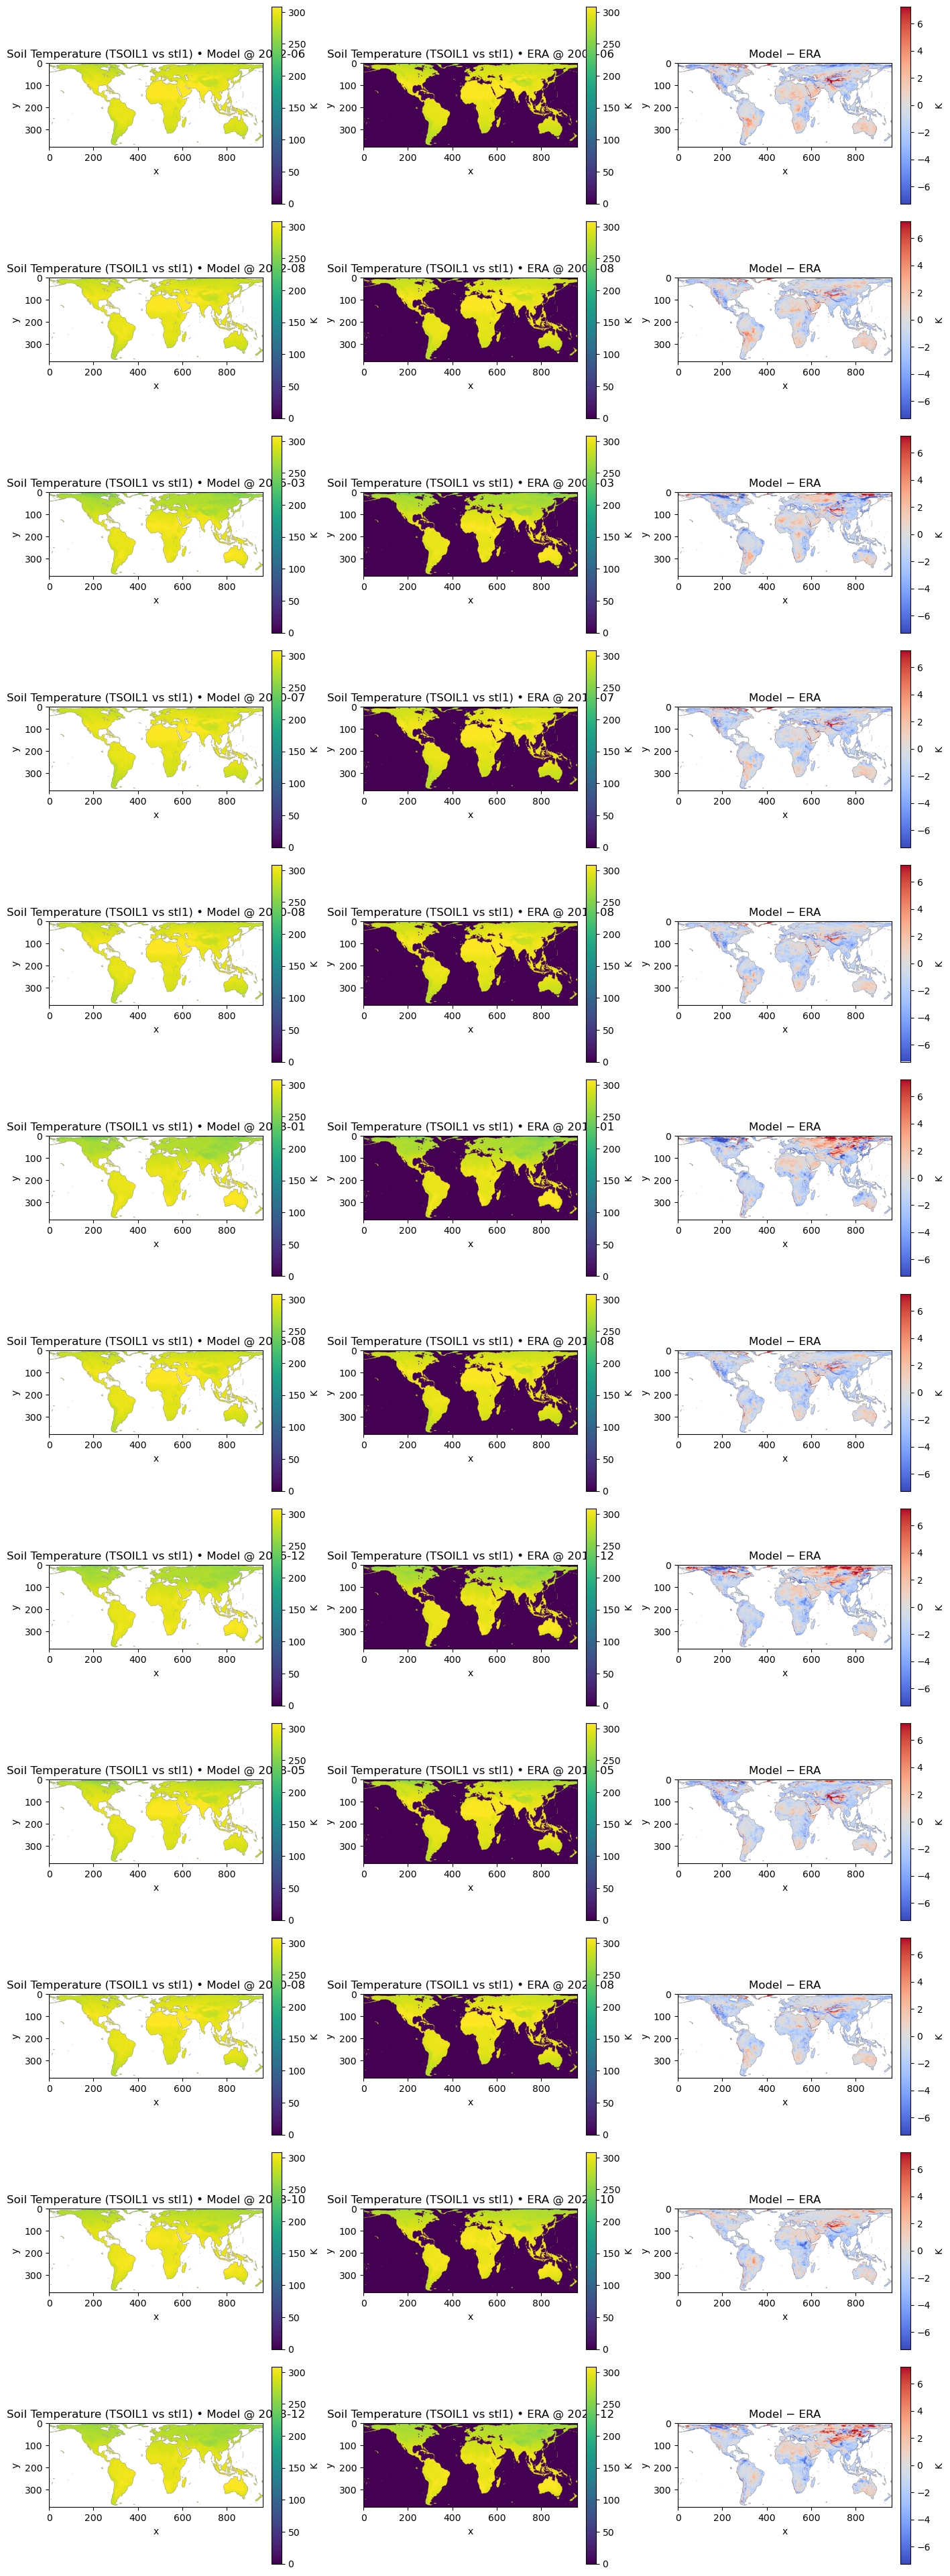


Soil Temperature (TSOIL1 vs stl1) • Overall across sampled months:
  MOD  min/max: [237.3350, 319.7650]
  ERA  min/max: [0.0000, 317.6949]
  DIFF min/max: [-18.5710, 38.2328]

Snow Cover Fraction (SCF)  2002-06  MOD[min,max]=[0.0000, 1.0000]  ERA[min,max]=[0.0000, 1.0000]  DIFF[min,max]=[-1.0000, 1.0000]
Snow Cover Fraction (SCF)  2002-08  MOD[min,max]=[0.0000, 1.0000]  ERA[min,max]=[0.0000, 1.0000]  DIFF[min,max]=[-1.0000, 1.0000]
Snow Cover Fraction (SCF)  2005-03  MOD[min,max]=[0.0000, 1.0000]  ERA[min,max]=[0.0000, 1.0000]  DIFF[min,max]=[-1.0000, 1.0000]
Snow Cover Fraction (SCF)  2010-07  MOD[min,max]=[0.0000, 1.0000]  ERA[min,max]=[0.0000, 1.0000]  DIFF[min,max]=[-1.0000, 1.0000]
Snow Cover Fraction (SCF)  2010-08  MOD[min,max]=[0.0000, 1.0000]  ERA[min,max]=[0.0000, 1.0000]  DIFF[min,max]=[-1.0000, 1.0000]
Snow Cover Fraction (SCF)  2013-01  MOD[min,max]=[0.0000, 1.0000]  ERA[min,max]=[0.0000, 1.0000]  DIFF[min,max]=[-1.0000, 1.0000]
Snow Cover Fraction (SCF)  2015-08  MOD[min

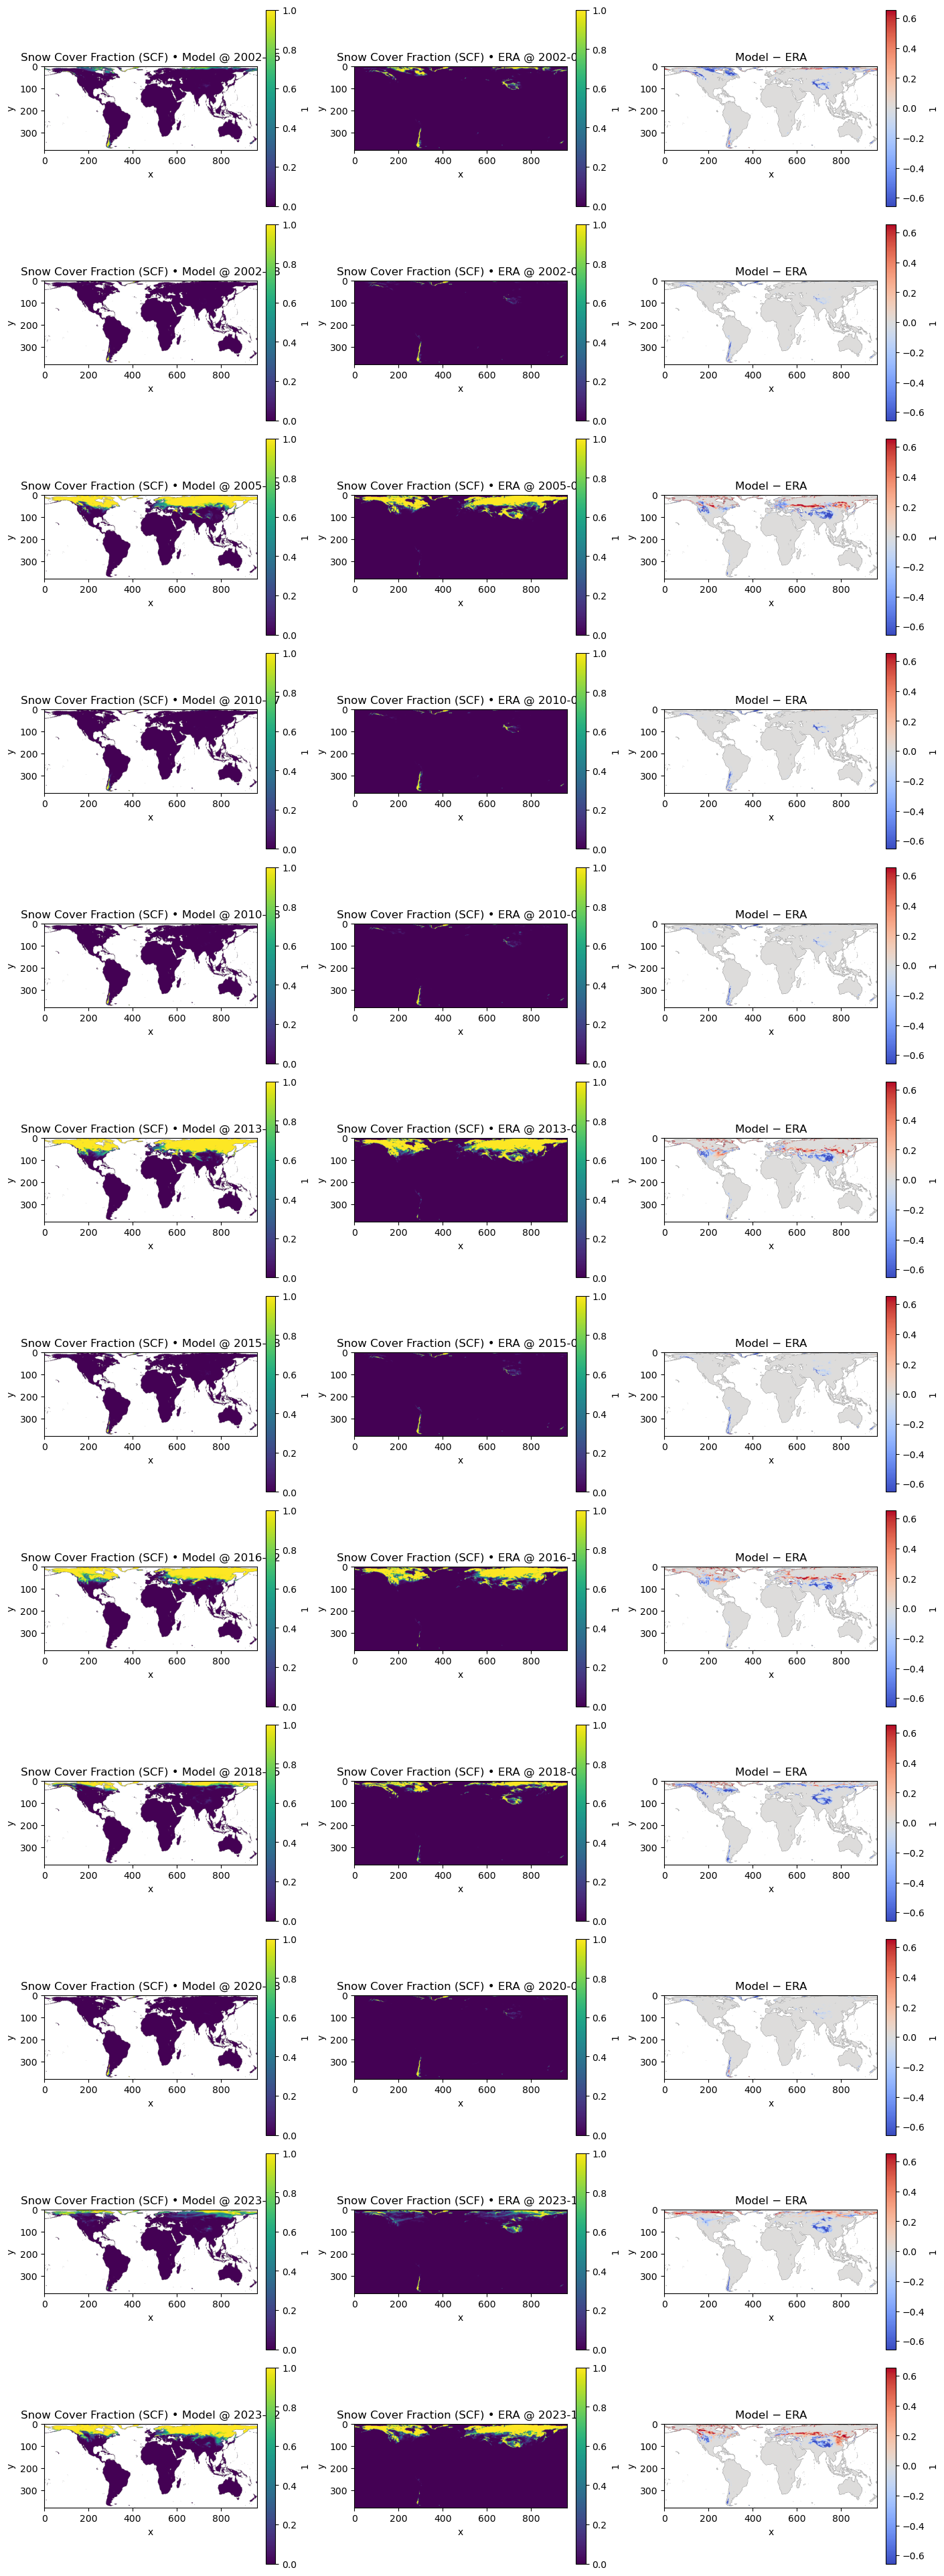


Snow Cover Fraction (SCF) • Overall across sampled months:
  MOD  min/max: [0.0000, 1.0000]
  ERA  min/max: [0.0000, 1.0000]
  DIFF min/max: [-1.0000, 1.0000]



In [7]:

# --- Random 12-month visual checks for SM, RZSM, Tsoil, SCF (with per-month min/max) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

def plot_random_months(mod_da, era_da, title, units, N_SAMPLES=12, SEED=42):
    # sanity
    assert mod_da.dims == era_da.dims == ("time","y","x"), f"{title}: dims mismatch or unexpected"
    assert (mod_da["time"].values == era_da["time"].values).all(), f"{title}: time coords differ"
    T = mod_da.sizes["time"]

    # pick months
    rng  = np.random.default_rng(SEED)
    idx  = rng.choice(T, size=min(N_SAMPLES, T), replace=False)
    idx.sort()
    times = pd.to_datetime(mod_da["time"].values[idx])

    # shared color limits across sampled months
    mod_sel  = mod_da.isel(time=idx)
    era_sel  = era_da.isel(time=idx)
    both_val = xr.concat([mod_sel, era_sel], dim="stack").values
    vmin = np.nanpercentile(both_val, 2)
    vmax = np.nanpercentile(both_val, 98)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = np.nanmin(both_val), np.nanmax(both_val)

    # diff symmetric limits
    diff_vals = (mod_sel - era_sel).values
    dabs = np.nanpercentile(np.abs(diff_vals), 98)
    if not np.isfinite(dabs) or dabs == 0:
        dabs = np.nanmax(np.abs(diff_vals)) if np.isfinite(np.nanmax(np.abs(diff_vals))) else 1.0

    # track overall min/max
    overall = {"mod_min": np.inf, "mod_max": -np.inf, "era_min": np.inf, "era_max": -np.inf, "dif_min": np.inf, "dif_max": -np.inf}

    # figure
    fig, axes = plt.subplots(len(idx), 3, figsize=(14, 3.2*len(idx)), constrained_layout=True)
    if len(idx) == 1:
        axes = np.array([axes])

    for r, t_i in enumerate(idx):
        ts = pd.to_datetime(mod_da["time"].values[t_i])
        mod_t = mod_da.isel(time=t_i)
        era_t = era_da.isel(time=t_i)
        diff  = mod_t - era_t

        # per-month min/max
        mmin, mmax = np.nanmin(mod_t.values),  np.nanmax(mod_t.values)
        emin, emax = np.nanmin(era_t.values),  np.nanmax(era_t.values)
        dmin, dmax = np.nanmin(diff.values),   np.nanmax(diff.values)
        print(f"{title}  {ts:%Y-%m}  MOD[min,max]=[{mmin:.4f}, {mmax:.4f}]  "
              f"ERA[min,max]=[{emin:.4f}, {emax:.4f}]  DIFF[min,max]=[{dmin:.4f}, {dmax:.4f}]")

        overall["mod_min"] = min(overall["mod_min"], mmin)
        overall["mod_max"] = max(overall["mod_max"], mmax)
        overall["era_min"] = min(overall["era_min"], emin)
        overall["era_max"] = max(overall["era_max"], emax)
        overall["dif_min"] = min(overall["dif_min"], dmin)
        overall["dif_max"] = max(overall["dif_max"], dmax)

        # plots
        im0 = axes[r, 0].imshow(mod_t, vmin=vmin, vmax=vmax)
        axes[r, 0].set_title(f"{title} • Model @ {ts:%Y-%m}")
        axes[r, 0].set_xlabel("x"); axes[r, 0].set_ylabel("y")
        cb0 = plt.colorbar(im0, ax=axes[r, 0], fraction=0.046, pad=0.04); cb0.set_label(units)

        im1 = axes[r, 1].imshow(era_t, vmin=vmin, vmax=vmax)
        axes[r, 1].set_title(f"{title} • ERA @ {ts:%Y-%m}")
        axes[r, 1].set_xlabel("x"); axes[r, 1].set_ylabel("y")
        cb1 = plt.colorbar(im1, ax=axes[r, 1], fraction=0.046, pad=0.04); cb1.set_label(units)

        im2 = axes[r, 2].imshow(diff, vmin=-dabs, vmax=dabs, cmap="coolwarm")
        axes[r, 2].set_title("Model − ERA")
        axes[r, 2].set_xlabel("x"); axes[r, 2].set_ylabel("y")
        cb2 = plt.colorbar(im2, ax=axes[r, 2], fraction=0.046, pad=0.04); cb2.set_label(units)

    plt.show()
    print(f"\n{title} • Overall across sampled months:")
    print(f"  MOD  min/max: [{overall['mod_min']:.4f}, {overall['mod_max']:.4f}]")
    print(f"  ERA  min/max: [{overall['era_min']:.4f}, {overall['era_max']:.4f}]")
    print(f"  DIFF min/max: [{overall['dif_min']:.4f}, {overall['dif_max']:.4f}]\n")

# ---- Call for each variable pair ----
plot_random_months(sfmc_aln,   era_sfc_aln,  title="Surface SM (SFMC vs swvl1)",        units="m³ m⁻³")
if 'rzmc_aln' in locals() and rzmc_aln is not None:
    plot_random_months(rzmc_aln, era_rz_aln, title="Root-zone SM (RZMC vs ERA RZ)",      units="m³ m⁻³")
plot_random_months(tsoil1_aln, era_t1_aln,   title="Soil Temperature (TSOIL1 vs stl1)",  units="K")
plot_random_months(scf_aln,    era_scf_aln,  title="Snow Cover Fraction (SCF)",          units="1")


In [8]:
# Inputs (aligned by time, dims = ("time","y","x")):
#   Model: tsoil1_aln (K), scf_aln (0–1)
#   ERA:   era_t1_aln (K), era_scf_aln (0–1)

# T and snow thresholds
TEMP_THRESH_K = 275.15   # 2°C
SNOW_EPS     = 1e-2      # treat <1% as "snow-free" after regridding

# Sanity: same time axis
assert (tsoil1_aln["time"].values == era_t1_aln["time"].values).all(), "Time coords differ between model and ERA."

# Per-dataset masks
mask_model = (tsoil1_aln > TEMP_THRESH_K) & (scf_aln    < SNOW_EPS)
mask_era   = (era_t1_aln > TEMP_THRESH_K) & (era_scf_aln < SNOW_EPS)

# Intersection (use this to mask SM for comparison)
mask_both  = mask_model & mask_era

# Snow-domain eligibility (for snow diagnostics only):
# a grid cell must have at least one snowy month in BOTH model and ERA.
ever_snow_both = ((scf_aln > SNOW_EPS).any(dim="time")) & ((era_scf_aln > SNOW_EPS).any(dim="time"))

# Quick coverage summary
def cov_str(m):
    frac = float(m.mean().values)  # fraction over all time,y,x
    return f"{100.0*frac:.1f}% of (time,y,x)"

print("Mask coverage:")
print("  Model-only mask  :", cov_str(mask_model))
print("  ERA-only mask    :", cov_str(mask_era))
print("  BOTH (intersection):", cov_str(mask_both))


Mask coverage:
  Model-only mask  : 23.3% of (time,y,x)
  ERA-only mask    : 22.6% of (time,y,x)
  BOTH (intersection): 22.1% of (time,y,x)


In [9]:
MIN_PAIRS = 24  # months required for stats

import gc

def _metric_pair(mod_da, era_da, mask_da, label, min_pairs=MIN_PAIRS):
    # Keep temporary arrays at float32 and free them immediately to avoid kernel OOM.
    mod_eval = mod_da.where(mask_da).astype("float32")
    era_eval = era_da.where(mask_da).astype("float32")

    # Raw-value metrics
    R, _ = anom_metrics_monthly(mod_eval, era_eval, min_pairs=min_pairs)
    rmse, bias = raw_metrics_monthly(mod_eval, era_eval, min_pairs=min_pairs)

    # Anomaly metrics
    mod_an = anomalies_monthly(mod_eval)
    era_an = anomalies_monthly(era_eval)
    anomR, ubRMSE = anom_metrics_monthly(mod_an, era_an, min_pairs=min_pairs)

    print(f"{label} — mean R:", float(R.mean(skipna=True).values),
          " mean anomR:", float(anomR.mean(skipna=True).values),
          " mean ubRMSE:", float(ubRMSE.mean(skipna=True).values),
          " mean RMSE:", float(rmse.mean(skipna=True).values),
          " mean bias:", float(bias.mean(skipna=True).values))

    del mod_eval, era_eval, mod_an, era_an
    gc.collect()
    return R, anomR, ubRMSE, rmse, bias

# 1) Surface SM (masked by intersection of warm/snow-free criteria)
R_sfc, anomR_sfc, ubRMSE_sfc, rmse_sfc, bias_sfc = _metric_pair(sfmc_aln, era_sfc_aln, mask_both, "Surface SM")

# 2) Root-zone SM (masked) — only if available
R_rz = anomR_rz = ubRMSE_rz = rmse_rz = bias_rz = None
if ('rzmc_aln' in locals() and rzmc_aln is not None and
    'era_rz_aln' in locals() and era_rz_aln is not None):
    R_rz, anomR_rz, ubRMSE_rz, rmse_rz, bias_rz = _metric_pair(rzmc_aln, era_rz_aln, mask_both, "Root-zone SM")
else:
    print("Root-zone SM not available; skipping RZ metrics.")

# 3) Snow Cover Fraction (restricted to ever_snow_both grid cells)
R_scf, anomR_scf, ubRMSE_scf, rmse_scf, bias_scf = _metric_pair(scf_aln, era_scf_aln, ever_snow_both, "SCF (ever_snow_both)")

# 4) SWE (restricted to ever_snow_both grid cells)
R_swe, anomR_swe, ubRMSE_swe, rmse_swe, bias_swe = _metric_pair(swe_model_aln, era_swe_aln, ever_snow_both, "SWE (ever_snow_both)")

# 5) Snow depth (restricted to ever_snow_both grid cells)
R_snwd, anomR_snwd, ubRMSE_snwd, rmse_snwd, bias_snwd = _metric_pair(snwd_model_aln, era_snwd_aln, ever_snow_both, "Snow depth (ever_snow_both)")

# Optional: keep outputs together for downstream use
metrics = xr.Dataset(
    dict(
        R_sfc=R_sfc, anomR_sfc=anomR_sfc, ubRMSE_sfc=ubRMSE_sfc, rmse_sfc=rmse_sfc, bias_sfc=bias_sfc,
        R_rz=R_rz if R_rz is not None else xr.full_like(anomR_sfc, np.nan),
        anomR_rz=anomR_rz if anomR_rz is not None else xr.full_like(anomR_sfc, np.nan),
        ubRMSE_rz=ubRMSE_rz if ubRMSE_rz is not None else xr.full_like(ubRMSE_sfc, np.nan),
        rmse_rz=rmse_rz if rmse_rz is not None else xr.full_like(ubRMSE_sfc, np.nan),
        bias_rz=bias_rz if bias_rz is not None else xr.full_like(ubRMSE_sfc, np.nan),
        R_scf=R_scf, anomR_scf=anomR_scf, ubRMSE_scf=ubRMSE_scf, rmse_scf=rmse_scf, bias_scf=bias_scf,
        R_swe=R_swe, anomR_swe=anomR_swe, ubRMSE_swe=ubRMSE_swe, rmse_swe=rmse_swe, bias_swe=bias_swe,
        R_snwd=R_snwd, anomR_snwd=anomR_snwd, ubRMSE_snwd=ubRMSE_snwd, rmse_snwd=rmse_snwd, bias_snwd=bias_snwd,
        ever_snow_both=ever_snow_both,
    )
)


Surface SM — mean anomR: 0.5997515320777893  mean ubRMSE: 0.02508389949798584  mean RMSE: 0.1049235463142395  mean bias: -0.015284653753042221
Root-zone SM — mean anomR: 0.47304829955101013  mean ubRMSE: 0.022912446409463882  mean RMSE: 0.11542832106351852  mean bias: 0.002730580512434244
SCF (ever_snow_both) — mean anomR: 0.5283293724060059  mean ubRMSE: 0.1072588637471199  mean RMSE: 0.18289098143577576  mean bias: -0.013610552065074444
SWE (ever_snow_both) — mean anomR: 0.572987973690033  mean ubRMSE: 0.015327604487538338  mean RMSE: 0.1858433336019516  mean bias: -0.15317468345165253
Snow depth (ever_snow_both) — mean anomR: 0.5735593438148499  mean ubRMSE: 0.058774083852767944  mean RMSE: 0.6803002953529358  mean bias: -0.5974268913269043


Surface SM: mean corr = 0.600, mean ubRMSE = 0.0251 m³ m⁻³, mean RMSE = 0.1049 m³ m⁻³, mean bias = -0.0153 m³ m⁻³
Root-zone SM: mean corr = 0.473, mean ubRMSE = 0.0229 m³ m⁻³, mean RMSE = 0.1154 m³ m⁻³, mean bias = 0.0027 m³ m⁻³
Snow Cover Fraction: mean corr = 0.528, mean ubRMSE = 0.1073 1, mean RMSE = 0.1829 1, mean bias = -0.0136 1
SWE: mean corr = 0.573, mean ubRMSE = 0.0153 m w.e., mean RMSE = 0.1858 m w.e., mean bias = -0.1532 m w.e.
Snow Depth: mean corr = 0.574, mean ubRMSE = 0.0588 m, mean RMSE = 0.6803 m, mean bias = -0.5974 m


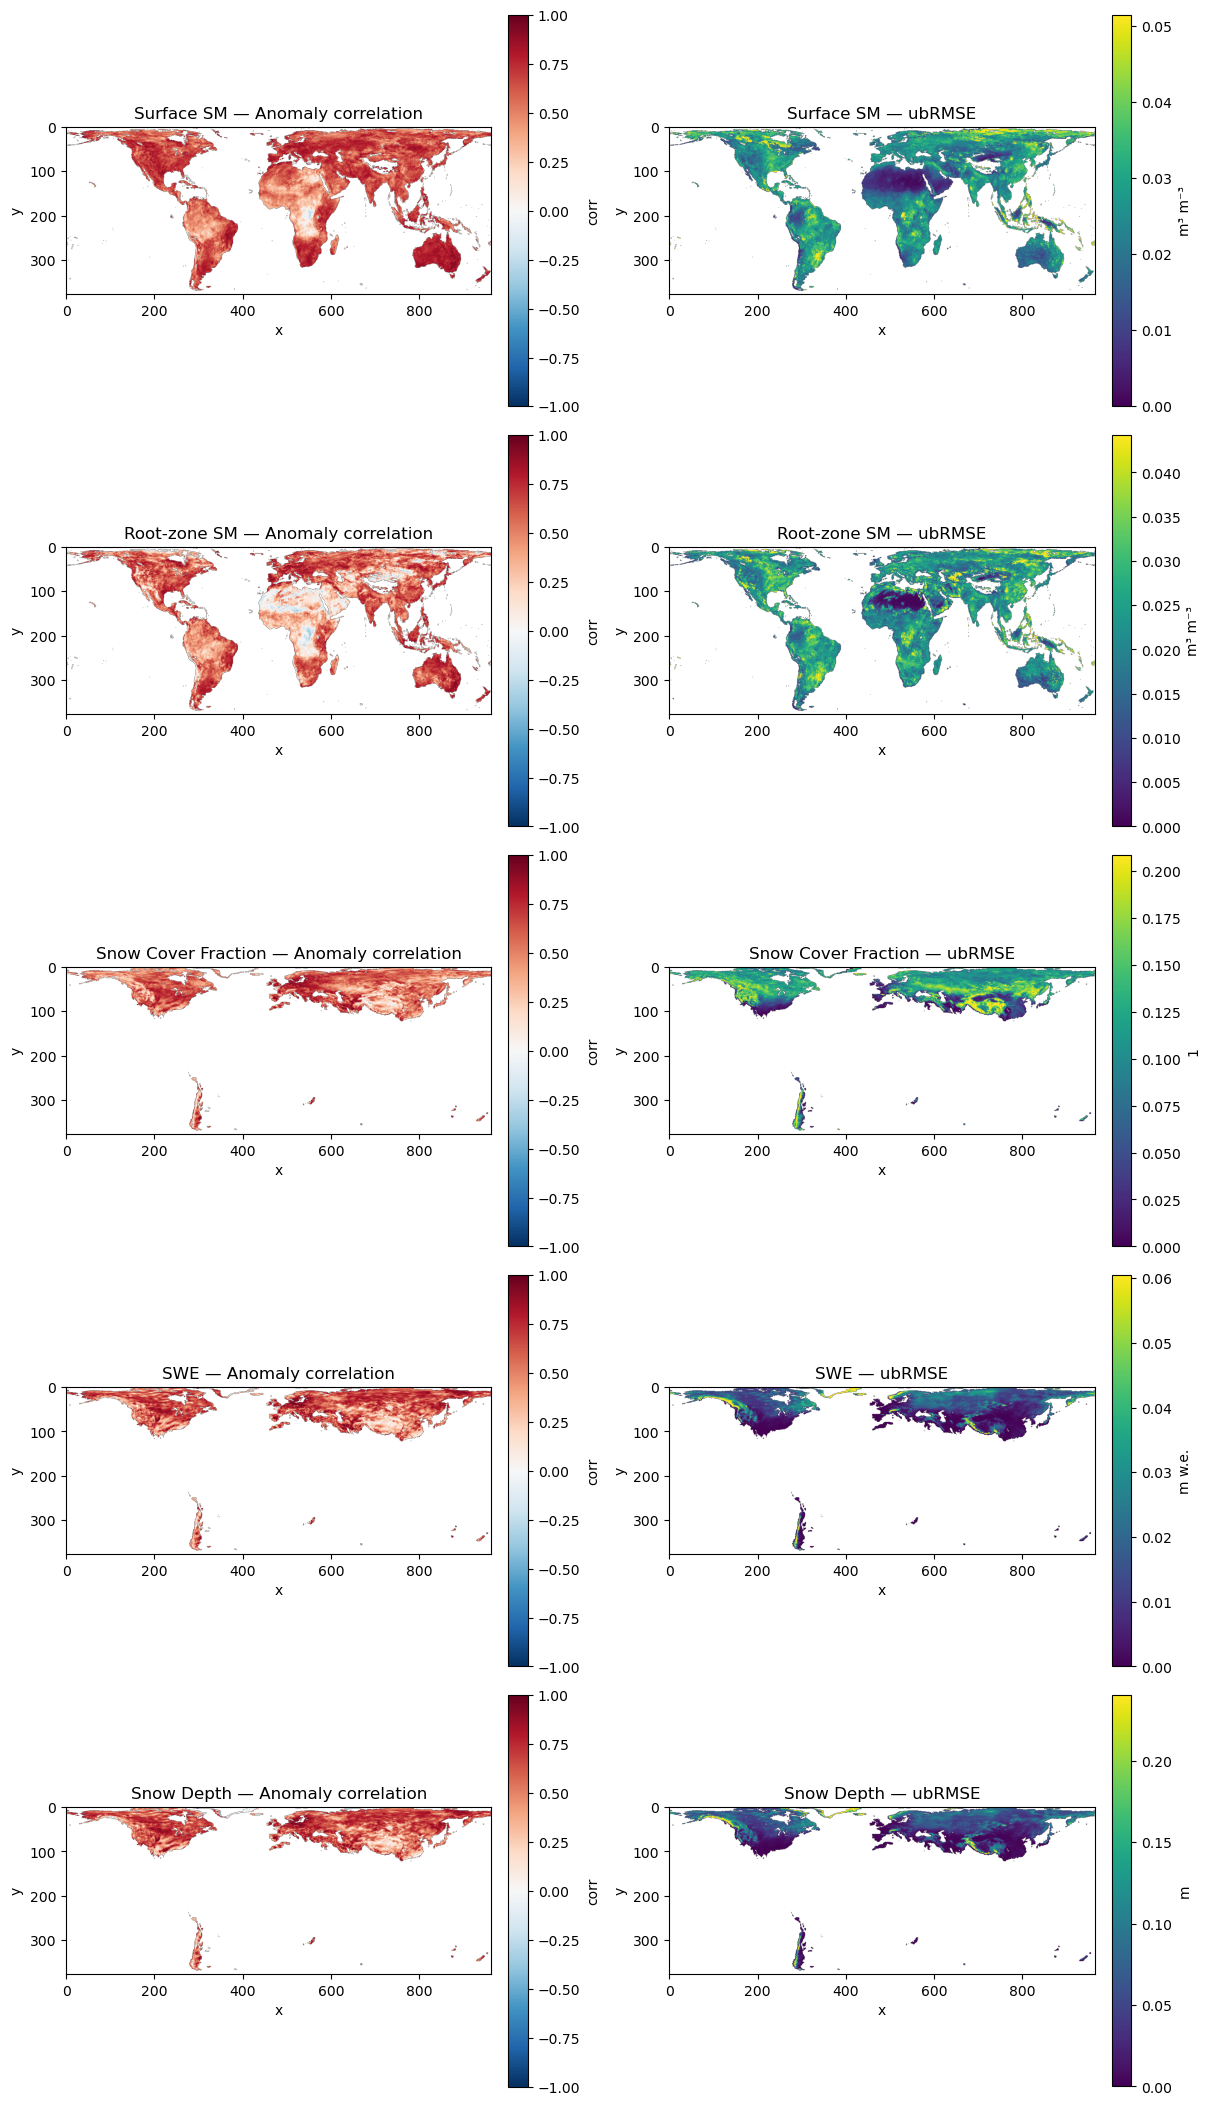

In [10]:
# --- Quick global maps of anomaly metrics ---

def robust_ub_range(m):
    """Robust upper bound for ubRMSE color scale."""
    v = np.asarray(m)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return 1.0
    ub = np.nanpercentile(v, 98)
    return 1.0 if not np.isfinite(ub) or ub <= 0 else float(ub)

rows = []
rows.append(("Surface SM", R_sfc, ubRMSE_sfc, rmse_sfc, bias_sfc, "m³ m⁻³"))
if 'anomR_rz' in locals() and anomR_rz is not None and np.any(np.isfinite(anomR_rz)):
    rows.append(("Root-zone SM", R_rz, ubRMSE_rz, rmse_rz, bias_rz, "m³ m⁻³"))
rows.append(("Snow Cover Fraction", R_scf, ubRMSE_scf, rmse_scf, bias_scf, "1"))
rows.append(("SWE", R_swe, ubRMSE_swe, rmse_swe, bias_swe, "m w.e."))
rows.append(("Snow Depth", R_snwd, ubRMSE_snwd, rmse_snwd, bias_snwd, "m"))

nrows = len(rows)
fig, axes = plt.subplots(nrows, 2, figsize=(12, 4.2*nrows), constrained_layout=True)
if nrows == 1:
    axes = np.array([axes])

for r, (title, anomR_da, ub_da, rmse_da, bias_da, units) in enumerate(rows):
    anomR = np.asarray(anomR_da)
    ub    = np.asarray(ub_da)

    im0 = axes[r, 0].imshow(anomR, vmin=-1, vmax=1, cmap="RdBu_r")
    axes[r, 0].set_title(f"{title} — Correlation")
    axes[r, 0].set_xlabel("x"); axes[r, 0].set_ylabel("y")
    cb0 = plt.colorbar(im0, ax=axes[r, 0], fraction=0.046, pad=0.04)
    cb0.set_label("R")

    vmax = robust_ub_range(ub)
    im1 = axes[r, 1].imshow(ub, vmin=0, vmax=vmax)
    axes[r, 1].set_title(f"{title} — ubRMSE")
    axes[r, 1].set_xlabel("x"); axes[r, 1].set_ylabel("y")
    cb1 = plt.colorbar(im1, ax=axes[r, 1], fraction=0.046, pad=0.04)
    cb1.set_label(units)

    mean_corr = float(np.nanmean(anomR))
    mean_ub   = float(np.nanmean(ub))
    mean_rmse = float(np.nanmean(np.asarray(rmse_da)))
    mean_bias = float(np.nanmean(np.asarray(bias_da)))
    print(f"{title}: mean R = {mean_corr:.3f}, mean ubRMSE = {mean_ub:.4f} {units}, mean RMSE = {mean_rmse:.4f} {units}, mean bias = {mean_bias:.4f} {units}")

plt.show()


In [11]:
# --- Save useful outputs to NetCDF (includes lat/lon) ---


def add_var(ds, name, da, attrs=None):
    if (name not in ds) and (da is not None):
        ds[name] = da
        if attrs:
            ds[name].attrs.update(attrs)

# Build dataset
ds_out = xr.Dataset()

# Coordinates (time, y, x)
ds_out = ds_out.assign_coords(
    time = sfmc_aln["time"].copy(),
    y    = sfmc_aln["y"].copy() if "y" in sfmc_aln.coords else xr.DataArray(np.arange(sfmc_aln.sizes["y"]), dims=("y",)),
    x    = sfmc_aln["x"].copy() if "x" in sfmc_aln.coords else xr.DataArray(np.arange(sfmc_aln.sizes["x"]), dims=("x",)),
    lat  = (("y","x"), m36_grid["lat"].values),
    lon  = (("y","x"), m36_grid["lon"].values),
)
ds_out["lat"].attrs.update(dict(standard_name="latitude",  units="degrees_north"))
ds_out["lon"].attrs.update(dict(standard_name="longitude", units="degrees_east"))

# Core aligned variables (monthly)
add_var(ds_out, "SM_model",   sfmc_aln.astype("float64"), dict(long_name="Model surface soil moisture", units="m3 m-3"))
add_var(ds_out, "SM_era",     era_sfc_aln.astype("float64"), dict(long_name="ERA5 swvl1", units="m3 m-3"))

if 'rzmc_aln' in locals() and rzmc_aln is not None:
    add_var(ds_out, "RZ_model", rzmc_aln.astype("float64"), dict(long_name="Model root-zone soil moisture", units="m3 m-3"))
if 'era_rz_aln' in locals() and era_rz_aln is not None:
    add_var(ds_out, "RZ_era",   era_rz_aln.astype("float64"), dict(long_name="ERA5 0–100 cm RZ proxy", units="m3 m-3"))

add_var(ds_out, "SCF_model",  scf_aln.astype("float64"), dict(long_name="Model snow cover fraction", units="1"))
add_var(ds_out, "SCF_era",    era_scf_aln.astype("float64"), dict(long_name="ERA5 snow cover fraction", units="1"))

add_var(ds_out, "SWE_model",  swe_model_aln.astype("float64"), dict(long_name="Model SWE", units="m"))
add_var(ds_out, "SWE_era",    era_swe_aln.astype("float64"), dict(long_name="ERA5 SWE", units="m"))
add_var(ds_out, "SNWD_model", snwd_model_aln.astype("float64"), dict(long_name="Model snow depth (SNODPLAND*FRLANDSNO)", units="m"))
add_var(ds_out, "SNWD_era",   era_snwd_aln.astype("float64"), dict(long_name="ERA5 snow depth", units="m"))

add_var(ds_out, "Tsoil_model", tsoil1_aln.astype("float64"), dict(long_name="Model soil temperature level 1", units="K"))
add_var(ds_out, "Tsoil_era",   era_t1_aln.astype("float64"), dict(long_name="ERA5 soil temperature level 1", units="K"))

# Masks
if 'mask_model' in locals():
    add_var(ds_out, "mask_model", mask_model.astype("bool"), dict(long_name="Model mask: T>2C & SCF≈0", units="1"))
if 'mask_era' in locals():
    add_var(ds_out, "mask_era",   mask_era.astype("bool"),   dict(long_name="ERA mask: T>2C & SCF≈0", units="1"))
if 'mask_both' in locals():
    add_var(ds_out, "mask_both",  mask_both.astype("bool"),  dict(long_name="Intersection mask (model & ERA)", units="1"))
if 'ever_snow_both' in locals():
    add_var(ds_out, "ever_snow_both", ever_snow_both.astype("bool"),
            dict(long_name="Snow-domain eligibility: snow occurs at least once in both model and ERA", units="1"))

# Metrics (spatial 2D)
if 'R_sfc' in locals():
    add_var(ds_out, "R_sfc",  R_sfc.astype("float64"),  dict(long_name="Correlation (surface SM)", units="1"))
if 'anomR_sfc' in locals():
    add_var(ds_out, "anomR_sfc",  anomR_sfc.astype("float64"),  dict(long_name="Anomaly correlation (surface SM)", units="1"))
if 'ubRMSE_sfc' in locals():
    add_var(ds_out, "ubRMSE_sfc", ubRMSE_sfc.astype("float64"), dict(long_name="ubRMSE (surface SM)", units="m3 m-3"))
if 'rmse_sfc' in locals():
    add_var(ds_out, "rmse_sfc", rmse_sfc.astype("float64"), dict(long_name="RMSE (surface SM)", units="m3 m-3"))
if 'bias_sfc' in locals():
    add_var(ds_out, "bias_sfc", bias_sfc.astype("float64"), dict(long_name="Bias (surface SM: model - ERA)", units="m3 m-3"))

if 'R_rz' in locals() and R_rz is not None:
    add_var(ds_out, "R_rz",   R_rz.astype("float64"),   dict(long_name="Correlation (root-zone SM)", units="1"))
if 'anomR_rz' in locals() and anomR_rz is not None:
    add_var(ds_out, "anomR_rz",   anomR_rz.astype("float64"),   dict(long_name="Anomaly correlation (root-zone SM)", units="1"))
if 'ubRMSE_rz' in locals() and ubRMSE_rz is not None:
    add_var(ds_out, "ubRMSE_rz",  ubRMSE_rz.astype("float64"),  dict(long_name="ubRMSE (root-zone SM)", units="m3 m-3"))
if 'rmse_rz' in locals() and rmse_rz is not None:
    add_var(ds_out, "rmse_rz", rmse_rz.astype("float64"), dict(long_name="RMSE (root-zone SM)", units="m3 m-3"))
if 'bias_rz' in locals() and bias_rz is not None:
    add_var(ds_out, "bias_rz", bias_rz.astype("float64"), dict(long_name="Bias (root-zone SM: model - ERA)", units="m3 m-3"))

if 'R_scf' in locals():
    add_var(ds_out, "R_scf",  R_scf.astype("float64"),  dict(long_name="Correlation (SCF)", units="1"))
if 'anomR_scf' in locals():
    add_var(ds_out, "anomR_scf",  anomR_scf.astype("float64"),  dict(long_name="Anomaly correlation (SCF)", units="1"))
if 'ubRMSE_scf' in locals():
    add_var(ds_out, "ubRMSE_scf", ubRMSE_scf.astype("float64"), dict(long_name="ubRMSE (SCF)", units="1"))
if 'rmse_scf' in locals():
    add_var(ds_out, "rmse_scf", rmse_scf.astype("float64"), dict(long_name="RMSE (SCF)", units="1"))
if 'bias_scf' in locals():
    add_var(ds_out, "bias_scf", bias_scf.astype("float64"), dict(long_name="Bias (SCF: model - ERA)", units="1"))

if 'R_swe' in locals():
    add_var(ds_out, "R_swe",  R_swe.astype("float64"),  dict(long_name="Correlation (SWE)", units="1"))
if 'anomR_swe' in locals():
    add_var(ds_out, "anomR_swe",  anomR_swe.astype("float64"),  dict(long_name="Anomaly correlation (SWE)", units="1"))
if 'ubRMSE_swe' in locals():
    add_var(ds_out, "ubRMSE_swe", ubRMSE_swe.astype("float64"), dict(long_name="ubRMSE (SWE)", units="m"))
if 'rmse_swe' in locals():
    add_var(ds_out, "rmse_swe", rmse_swe.astype("float64"), dict(long_name="RMSE (SWE)", units="m"))
if 'bias_swe' in locals():
    add_var(ds_out, "bias_swe", bias_swe.astype("float64"), dict(long_name="Bias (SWE: model - ERA)", units="m"))

if 'R_snwd' in locals():
    add_var(ds_out, "R_snwd",  R_snwd.astype("float64"),  dict(long_name="Correlation (snow depth)", units="1"))
if 'anomR_snwd' in locals():
    add_var(ds_out, "anomR_snwd",  anomR_snwd.astype("float64"),  dict(long_name="Anomaly correlation (snow depth)", units="1"))
if 'ubRMSE_snwd' in locals():
    add_var(ds_out, "ubRMSE_snwd", ubRMSE_snwd.astype("float64"), dict(long_name="ubRMSE (snow depth)", units="m"))
if 'rmse_snwd' in locals():
    add_var(ds_out, "rmse_snwd", rmse_snwd.astype("float64"), dict(long_name="RMSE (snow depth)", units="m"))
if 'bias_snwd' in locals():
    add_var(ds_out, "bias_snwd", bias_snwd.astype("float64"), dict(long_name="Bias (snow depth: model - ERA)", units="m"))

# Global attributes
ds_out.attrs.update(OrderedDict(
    title      = "ERA5 vs Model (M36) aligned fields, masks, and comparison metrics",
    conventions= "CF-1.8",
    note       = "SM fields masked with (T>2C & SCF≈0); SCF/SWE/snow-depth metrics restricted to ever_snow_both grid cells; includes R, anomR, ubRMSE, RMSE, and bias.",
))

# Encodings for compression
encoding = {}
for v in ds_out.data_vars:
    if str(ds_out[v].dtype).startswith(("bool",)):
        encoding[v] = dict(zlib=True, complevel=4, dtype="int8", _FillValue=0)
    else:
        encoding[v] = dict(zlib=True, complevel=4, dtype="float32", _FillValue=np.float32(np.nan))

encoding["lat"] = dict(zlib=True, complevel=4, dtype="float32", _FillValue=np.float32(np.nan))
encoding["lon"] = dict(zlib=True, complevel=4, dtype="float32", _FillValue=np.float32(np.nan))

# Save
ds_out.to_netcdf(out_nc, format="NETCDF4", encoding=encoding)
print(f"Saved: {out_nc}")
print("Variables saved:", list(ds_out.data_vars))


Saved: ERA5_vs_OLv8_M36_summary.nc
Variables saved: ['SM_model', 'SM_era', 'RZ_model', 'RZ_era', 'SCF_model', 'SCF_era', 'SWE_model', 'SWE_era', 'SNWD_model', 'SNWD_era', 'Tsoil_model', 'Tsoil_era', 'mask_model', 'mask_era', 'mask_both', 'ever_snow_both', 'anomR_sfc', 'ubRMSE_sfc', 'rmse_sfc', 'bias_sfc', 'anomR_rz', 'ubRMSE_rz', 'rmse_rz', 'bias_rz', 'anomR_scf', 'ubRMSE_scf', 'rmse_scf', 'bias_scf', 'anomR_swe', 'ubRMSE_swe', 'rmse_swe', 'bias_swe', 'anomR_snwd', 'ubRMSE_snwd', 'rmse_snwd', 'bias_snwd']
